# 팀원 공유용 설명판 + 시각화 버전
## 현재 최고점 구조 설명 + 비전공자용 그래프 추가

이 노트북은
- **현재 최고점 구조 설명**
- **각 코드의 쓰임 / 왜 넣었는지 주석**
- **비전공자도 이해하기 쉬운 시각화 자료**

를 함께 넣은 버전입니다.

현재 최고 구조 핵심:
1. 참여율(rate) 먼저 예측
2. 중식/석식 분리 모델
3. 메뉴 weak correction
4. 날씨 weak correction
5. holiday weak correction
6. 석식 holiday_after = +0.005


In [2]:
# 이 셀의 쓰임:
# 필요한 라이브러리가 없을 때만 설치하는 칸입니다.
# 왜 넣었나:
# 팀원들의 실행 환경이 다를 수 있어서, 실행이 안 될 때 빠르게 맞추기 위해 넣었습니다.

# !pip install xgboost scikit-learn


In [3]:
# 이 셀의 쓰임:
# 데이터 처리, 시각화, 모델 학습에 필요한 기본 라이브러리를 불러옵니다.
# 왜 넣었나:
# pandas는 표 처리, numpy는 계산, matplotlib는 그래프, xgboost는 예측 모델 학습에 사용합니다.

import os
import re
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
from xgboost import XGBRegressor

SEED = 42
random.seed(SEED)
np.random.seed(SEED)


In [4]:
# 이 셀의 쓰임:
# 그래프에서 한글이 깨지지 않도록 matplotlib 폰트를 자동으로 설정합니다.
# 왜 넣었나:
# Windows, Mac, Linux 환경마다 기본 한글 폰트가 달라서,
# 환경에 맞는 폰트를 자동으로 찾아 적용해야 그래프 제목과 축 이름이 정상적으로 보입니다.

import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams

available_fonts = {f.name for f in font_manager.fontManager.ttflist}
candidate_fonts = [
    "Malgun Gothic",   # Windows
    "AppleGothic",     # macOS
    "NanumGothic",     # Linux/Colab 등
    "NanumBarunGothic",
    "Noto Sans CJK KR",
    "Noto Sans KR",
]

selected_font = None
for font_name in candidate_fonts:
    if font_name in available_fonts:
        selected_font = font_name
        break

if selected_font is not None:
    rcParams["font.family"] = selected_font
    print(f"적용된 한글 폰트: {selected_font}")
else:
    print("사용 가능한 한글 폰트를 찾지 못했습니다. 그래프 한글이 깨질 수 있습니다.")

rcParams["axes.unicode_minus"] = False



적용된 한글 폰트: Malgun Gothic


In [5]:
# 이 셀의 쓰임:
# train / test / sample_submission / weather 파일 경로를 자동으로 찾습니다.
# 왜 넣었나:
# 팀원마다 파일 위치가 달라도 바로 실행할 수 있게 만들기 위해 넣었습니다.

train_candidates = [
    r"./data/train_median.csv",
]
test_candidates = [
    r"./data/test.csv",
]
sample_sub_candidates = [
    r"./data/sample_submission.csv",
]
weather_candidates = [
    r"./data/weather.csv",
]

def find_existing_path(candidates):
    for p in candidates:
        if os.path.exists(p):
            return p
    return None

train_path = find_existing_path(train_candidates)
test_path = find_existing_path(test_candidates)
sample_sub_path = find_existing_path(sample_sub_candidates)
weather_path = find_existing_path(weather_candidates)

print("train_path:", train_path)
print("test_path:", test_path)
print("sample_sub_path:", sample_sub_path)
print("weather_path:", weather_path)

if train_path is None or test_path is None or sample_sub_path is None or weather_path is None:
    raise FileNotFoundError("필요 파일 경로를 찾지 못했습니다.")


train_path: ./data/train_median.csv
test_path: ./data/test.csv
sample_sub_path: ./data/sample_submission.csv
weather_path: ./data/weather.csv


In [6]:
# 이 셀의 쓰임:
# 실제 CSV를 불러오고 날짜를 datetime 형식으로 변환합니다.
# 왜 넣었나:
# 날짜 기반 그래프, 날씨 병합, holiday 계산을 하려면 날짜 형식이 필요합니다.

train = pd.read_csv(train_path, encoding="utf-8-sig")
test = pd.read_csv(test_path, encoding="utf-8-sig")
sample_submission = pd.read_csv(sample_sub_path, encoding="utf-8-sig")
weather = pd.read_csv(weather_path, encoding="utf-8-sig")

train["일자"] = pd.to_datetime(train["일자"])
test["일자"] = pd.to_datetime(test["일자"])

display(train.head())
display(test.head())
display(weather.head())


,일자,요일,본사정원수,본사휴가자수,본사출장자수,본사시간외근무명령서승인건수,현본사소속재택근무자수,조식메뉴,중식메뉴,석식메뉴,중식계,석식계
0,2016-02-01,월,2601,50,150,238,0.0,모닝롤/찐빵 우유/두유/주스 계란후라이 호두죽/쌀밥 (쌀:국내산) 된장찌개 쥐...,"쌀밥/잡곡밥 (쌀,현미흑미:국내산) 오징어찌개 쇠불고기 (쇠고기:호주산) 계란찜 ...","쌀밥/잡곡밥 (쌀,현미흑미:국내산) 육개장 자반고등어구이 두부조림 건파래무침 ...",1039.0,331.0
1,2016-02-02,화,2601,50,173,319,0.0,모닝롤/단호박샌드 우유/두유/주스 계란후라이 팥죽/쌀밥 (쌀:국내산) 호박젓국찌...,"쌀밥/잡곡밥 (쌀,현미흑미:국내산) 김치찌개 가자미튀김 모둠소세지구이 마늘쫑무...","콩나물밥*양념장 (쌀,현미흑미:국내산) 어묵국 유산슬 (쇠고기:호주산) 아삭고추무...",867.0,560.0
2,2016-02-03,수,2601,56,180,111,0.0,모닝롤/베이글 우유/두유/주스 계란후라이 표고버섯죽/쌀밥 (쌀:국내산) 콩나물국...,"카레덮밥 (쌀,현미흑미:국내산) 팽이장국 치킨핑거 (닭고기:국내산) 쫄면야채무침 ...","쌀밥/잡곡밥 (쌀,현미흑미:국내산) 청국장찌개 황태양념구이 (황태:러시아산) 고기...",1017.0,573.0
3,2016-02-04,목,2601,104,220,355,0.0,"모닝롤/토마토샌드 우유/두유/주스 계란후라이 닭죽/쌀밥 (쌀,닭:국내산) 근대국...","쌀밥/잡곡밥 (쌀,현미흑미:국내산) 쇠고기무국 주꾸미볶음 부추전 시금치나물 ...","미니김밥*겨자장 (쌀,현미흑미:국내산) 우동 멕시칸샐러드 군고구마 무피클 포...",978.0,525.0
4,2016-02-05,금,2601,278,181,34,0.0,모닝롤/와플 우유/두유/주스 계란후라이 쇠고기죽/쌀밥 (쌀:국내산) 재첩국 방...,"쌀밥/잡곡밥 (쌀,현미흑미:국내산) 떡국 돈육씨앗강정 (돼지고기:국내산) 우엉잡채...","쌀밥/잡곡밥 (쌀,현미흑미:국내산) 차돌박이찌개 (쇠고기:호주산) 닭갈비 (닭고기:...",925.0,330.0


,일자,요일,본사정원수,본사휴가자수,본사출장자수,본사시간외근무명령서승인건수,현본사소속재택근무자수,조식메뉴,중식메뉴,석식메뉴
0,2021-01-27,수,2983,88,182,5,358.0,모닝롤/연유버터베이글 우유/주스 계란후라이/찐계란 단호박죽/흑미밥 우거지국 고기완자...,쌀밥/흑미밥/찰현미밥 대구지리 매운돈갈비찜 오꼬노미계란말이 상추무침 포기김치 양상추...,흑미밥 얼큰순두부찌개 쇠고기우엉볶음 버섯햄볶음 (New)아삭이고추무절임 포기김치
1,2021-01-28,목,2983,104,212,409,348.0,모닝롤/대만샌드위치 우유/주스 계란후라이/찐계란 누룽지탕/흑미밥 황태국 시래기지짐 ...,쌀밥/보리밥/찰현미밥 우렁된장찌개 오리주물럭 청양부추전 수제삼색무쌈 겉절이김치 양상...,충무김밥 우동국물 오징어무침 꽃맛살샐러드 얼갈이쌈장무침 석박지
2,2021-01-29,금,2983,270,249,0,294.0,모닝롤/핫케익 우유/주스 계란후라이/찐계란 오곡죽/흑미밥 매생이굴국 고구마순볶음 양...,쌀밥/흑미밥/찰현미밥 팽이장국 수제돈까스*소스 가자미조림 동초나물무침 포기김치 양상...,흑미밥 물만둣국 카레찜닭 숯불양념꼬지어묵 꼬시래기무침 포기김치
3,2021-02-01,월,2924,108,154,538,322.0,모닝롤/촉촉한치즈케익 우유/주스 계란후라이/찐계란 누룽지탕/흑미밥 두부김칫국 새우완...,쌀밥/흑미밥/찰현미밥 배추들깨국 오리대패불고기 시금치프리타타 부추고추장무침 포기김치...,흑미밥 동태탕 돈육꽈리고추장조림 당면채소무침 모자반무침 포기김치
4,2021-02-02,화,2924,62,186,455,314.0,모닝롤/토마토샌드 우유/주스 계란후라이/찐계란 채소죽/흑미밥 호박맑은국 오이생채 양...,쌀밥/팥밥/찰현미밥 부대찌개 닭살데리야끼조림 버섯탕수 세발나물무침 알타리김치/사과푸...,흑미밥 바지락살국 쇠고기청경채볶음 두부구이*볶은김치 머위된장무침 백김치


,지점,지점명,일시,기온,강수량,풍속,습도,일사량,적설,전운량,지면온도
0,192,진주,2016-02-01,-0.6,NaN,1.3,43.9,9.56,NaN,NaN,2.3
1,192,진주,2016-02-02,-2.3,NaN,0.8,47.5,10.40,NaN,NaN,1.2
2,192,진주,2016-02-03,-1.7,NaN,0.6,57.1,10.32,NaN,NaN,1.3
3,192,진주,2016-02-04,-0.2,NaN,0.7,53.4,6.60,NaN,NaN,1.0
4,192,진주,2016-02-05,1.3,NaN,1.0,44.4,10.32,NaN,NaN,2.4


## 데이터 구조 먼저 확인하기

비전공자 팀원도 데이터가 어떻게 생겼는지 먼저 볼 수 있도록,
`head()`와 `info()`를 확인하는 셀을 추가했습니다.


In [7]:
# 이 셀의 쓰임:
# train / test / weather 데이터의 앞부분(head)과 전체 구조(info)를 확인합니다.
# 왜 넣었나:
# 데이터가 어떤 컬럼으로 이루어져 있고, 타입이 무엇인지, 결측치가 있는지
# 비전공자도 먼저 눈으로 확인할 수 있게 하기 위해 넣었습니다.

print("=== train.head() ===")
display(train.head())

print("=== test.head() ===")
display(test.head())

print("=== weather.head() ===")
display(weather.head())

print("\n=== train.info() ===")
train.info()

print("\n=== test.info() ===")
test.info()

print("\n=== weather.info() ===")
weather.info()



=== train.head() ===


,일자,요일,본사정원수,본사휴가자수,본사출장자수,본사시간외근무명령서승인건수,현본사소속재택근무자수,조식메뉴,중식메뉴,석식메뉴,중식계,석식계
0,2016-02-01,월,2601,50,150,238,0.0,모닝롤/찐빵 우유/두유/주스 계란후라이 호두죽/쌀밥 (쌀:국내산) 된장찌개 쥐...,"쌀밥/잡곡밥 (쌀,현미흑미:국내산) 오징어찌개 쇠불고기 (쇠고기:호주산) 계란찜 ...","쌀밥/잡곡밥 (쌀,현미흑미:국내산) 육개장 자반고등어구이 두부조림 건파래무침 ...",1039.0,331.0
1,2016-02-02,화,2601,50,173,319,0.0,모닝롤/단호박샌드 우유/두유/주스 계란후라이 팥죽/쌀밥 (쌀:국내산) 호박젓국찌...,"쌀밥/잡곡밥 (쌀,현미흑미:국내산) 김치찌개 가자미튀김 모둠소세지구이 마늘쫑무...","콩나물밥*양념장 (쌀,현미흑미:국내산) 어묵국 유산슬 (쇠고기:호주산) 아삭고추무...",867.0,560.0
2,2016-02-03,수,2601,56,180,111,0.0,모닝롤/베이글 우유/두유/주스 계란후라이 표고버섯죽/쌀밥 (쌀:국내산) 콩나물국...,"카레덮밥 (쌀,현미흑미:국내산) 팽이장국 치킨핑거 (닭고기:국내산) 쫄면야채무침 ...","쌀밥/잡곡밥 (쌀,현미흑미:국내산) 청국장찌개 황태양념구이 (황태:러시아산) 고기...",1017.0,573.0
3,2016-02-04,목,2601,104,220,355,0.0,"모닝롤/토마토샌드 우유/두유/주스 계란후라이 닭죽/쌀밥 (쌀,닭:국내산) 근대국...","쌀밥/잡곡밥 (쌀,현미흑미:국내산) 쇠고기무국 주꾸미볶음 부추전 시금치나물 ...","미니김밥*겨자장 (쌀,현미흑미:국내산) 우동 멕시칸샐러드 군고구마 무피클 포...",978.0,525.0
4,2016-02-05,금,2601,278,181,34,0.0,모닝롤/와플 우유/두유/주스 계란후라이 쇠고기죽/쌀밥 (쌀:국내산) 재첩국 방...,"쌀밥/잡곡밥 (쌀,현미흑미:국내산) 떡국 돈육씨앗강정 (돼지고기:국내산) 우엉잡채...","쌀밥/잡곡밥 (쌀,현미흑미:국내산) 차돌박이찌개 (쇠고기:호주산) 닭갈비 (닭고기:...",925.0,330.0


=== test.head() ===


,일자,요일,본사정원수,본사휴가자수,본사출장자수,본사시간외근무명령서승인건수,현본사소속재택근무자수,조식메뉴,중식메뉴,석식메뉴
0,2021-01-27,수,2983,88,182,5,358.0,모닝롤/연유버터베이글 우유/주스 계란후라이/찐계란 단호박죽/흑미밥 우거지국 고기완자...,쌀밥/흑미밥/찰현미밥 대구지리 매운돈갈비찜 오꼬노미계란말이 상추무침 포기김치 양상추...,흑미밥 얼큰순두부찌개 쇠고기우엉볶음 버섯햄볶음 (New)아삭이고추무절임 포기김치
1,2021-01-28,목,2983,104,212,409,348.0,모닝롤/대만샌드위치 우유/주스 계란후라이/찐계란 누룽지탕/흑미밥 황태국 시래기지짐 ...,쌀밥/보리밥/찰현미밥 우렁된장찌개 오리주물럭 청양부추전 수제삼색무쌈 겉절이김치 양상...,충무김밥 우동국물 오징어무침 꽃맛살샐러드 얼갈이쌈장무침 석박지
2,2021-01-29,금,2983,270,249,0,294.0,모닝롤/핫케익 우유/주스 계란후라이/찐계란 오곡죽/흑미밥 매생이굴국 고구마순볶음 양...,쌀밥/흑미밥/찰현미밥 팽이장국 수제돈까스*소스 가자미조림 동초나물무침 포기김치 양상...,흑미밥 물만둣국 카레찜닭 숯불양념꼬지어묵 꼬시래기무침 포기김치
3,2021-02-01,월,2924,108,154,538,322.0,모닝롤/촉촉한치즈케익 우유/주스 계란후라이/찐계란 누룽지탕/흑미밥 두부김칫국 새우완...,쌀밥/흑미밥/찰현미밥 배추들깨국 오리대패불고기 시금치프리타타 부추고추장무침 포기김치...,흑미밥 동태탕 돈육꽈리고추장조림 당면채소무침 모자반무침 포기김치
4,2021-02-02,화,2924,62,186,455,314.0,모닝롤/토마토샌드 우유/주스 계란후라이/찐계란 채소죽/흑미밥 호박맑은국 오이생채 양...,쌀밥/팥밥/찰현미밥 부대찌개 닭살데리야끼조림 버섯탕수 세발나물무침 알타리김치/사과푸...,흑미밥 바지락살국 쇠고기청경채볶음 두부구이*볶은김치 머위된장무침 백김치


=== weather.head() ===


,지점,지점명,일시,기온,강수량,풍속,습도,일사량,적설,전운량,지면온도
0,192,진주,2016-02-01,-0.6,NaN,1.3,43.9,9.56,NaN,NaN,2.3
1,192,진주,2016-02-02,-2.3,NaN,0.8,47.5,10.40,NaN,NaN,1.2
2,192,진주,2016-02-03,-1.7,NaN,0.6,57.1,10.32,NaN,NaN,1.3
3,192,진주,2016-02-04,-0.2,NaN,0.7,53.4,6.60,NaN,NaN,1.0
4,192,진주,2016-02-05,1.3,NaN,1.0,44.4,10.32,NaN,NaN,2.4



=== train.info() ===
<class 'pandas.DataFrame'>
RangeIndex: 1217 entries, 0 to 1216
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   일자              1217 non-null   datetime64[us]
 1   요일              1217 non-null   str           
 2   본사정원수           1217 non-null   int64         
 3   본사휴가자수          1217 non-null   int64         
 4   본사출장자수          1217 non-null   int64         
 5   본사시간외근무명령서승인건수  1217 non-null   int64         
 6   현본사소속재택근무자수     1217 non-null   float64       
 7   조식메뉴            1217 non-null   str           
 8   중식메뉴            1217 non-null   str           
 9   석식메뉴            1217 non-null   str           
 10  중식계             1217 non-null   float64       
 11  석식계             1217 non-null   float64       
dtypes: datetime64[us](1), float64(3), int64(4), str(4)
memory usage: 114.2 KB

=== test.info() ===
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 t

In [8]:
# 이 셀의 쓰임:
# 날씨 데이터에서 날짜 / 기온 / 강수량을 정리하고 비/더위/추위 플래그를 만듭니다.
# 왜 넣었나:
# 날씨를 직접 강한 feature로 넣는 것보다, 단순 신호를 약한 보정으로 쓰는 게 더 잘 맞았기 때문입니다.

def find_col(cols, candidates):
    for cand in candidates:
        for c in cols:
            if cand.lower() == c.lower():
                return c
        for c in cols:
            if cand.lower() in c.lower():
                return c
    return None

date_col = find_col(weather.columns, ["일시", "date", "날짜"])
temp_col = find_col(weather.columns, ["기온", "평균기온", "temperature", "avg_temp"])
rain_col = find_col(weather.columns, ["강수량", "rainfall", "precipitation", "rain"])

if date_col is None or temp_col is None or rain_col is None:
    raise ValueError("날씨 파일의 날짜/기온/강수 컬럼을 찾지 못했습니다.")

weather = weather[[date_col, temp_col, rain_col]].copy()
weather = weather.rename(columns={date_col:"일자", temp_col:"기온", rain_col:"강수량"})
weather["일자"] = pd.to_datetime(weather["일자"])
weather["기온"] = pd.to_numeric(weather["기온"], errors="coerce")
weather["강수량"] = pd.to_numeric(weather["강수량"], errors="coerce")
weather["강수량"] = weather["강수량"].fillna(0)
weather["기온"] = weather["기온"].interpolate().bfill().ffill()

weather["is_rain"] = (weather["강수량"] > 0).astype(int)
weather["is_hot"] = (weather["기온"] >= 28).astype(int)
weather["is_cold"] = (weather["기온"] <= 5).astype(int)

train = train.merge(weather, on="일자", how="left")
test = test.merge(weather, on="일자", how="left")

for df_ in [train, test]:
    for c in ["기온","강수량","is_rain","is_hot","is_cold"]:
        if c.startswith("is_"):
            df_[c] = df_[c].fillna(0)
        else:
            df_[c] = df_[c].interpolate().bfill().ffill()


In [9]:
# 이 셀의 쓰임:
# 기본 날짜/운영 파생변수와 holiday_before / holiday_after를 만듭니다.
# 왜 넣었나:
# 식수 인원 자체보다 참여율 예측이 더 잘 맞았고, 연휴 전/후는 실제 식수 행동을 흔드는 요인이었기 때문입니다.

def normalize_menu_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = text.replace("\n", " ").replace("\r", " ").replace("/", " ").replace("&", " ").replace("+", " ")
    text = text.replace("(", " ").replace(")", " ")
    text = re.sub(r"[^가-힣A-Za-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def add_features(df):
    df = df.copy().sort_values("일자").reset_index(drop=True)
    df["월"] = df["일자"].dt.month
    df["일"] = df["일자"].dt.day
    df["요일"] = df["일자"].dt.weekday
    df["식사가능자수"] = (
        df["본사정원수"] - df["본사휴가자수"] - df["본사출장자수"] - df["현본사소속재택근무자수"]
    ).clip(lower=1)

    month_end = df["일자"] + pd.offsets.MonthEnd(0)
    df["days_to_month_end"] = (month_end - df["일자"]).dt.days
    df["is_month_end_part"] = (df["days_to_month_end"] <= 5).astype(int)
    df["is_wed"] = (df["요일"] == 2).astype(int)
    df["is_fri"] = (df["요일"] == 4).astype(int)
    df["has_overtime"] = (df["본사시간외근무명령서승인건수"] > 0).astype(int)
    df["log_overtime"] = np.log1p(df["본사시간외근무명령서승인건수"])

    prev_gap = df["일자"].diff().dt.days.fillna(1)
    next_gap = df["일자"].shift(-1).sub(df["일자"]).dt.days.fillna(1)
    df["holiday_after"] = (prev_gap >= 2).astype(int)
    df["holiday_before"] = (next_gap >= 2).astype(int)

    return df

train = add_features(train)
test = add_features(test)

train["중식참여율"] = (train["중식계"] / train["식사가능자수"]).clip(lower=0, upper=1.5)
train["석식참여율"] = (train["석식계"] / train["식사가능자수"]).clip(lower=0, upper=1.5)


In [10]:
# 이 셀의 쓰임:
# 시각화용으로 요일 이름을 보기 쉽게 붙입니다.
# 왜 넣었나:
# 비전공자 팀원들이 숫자 요일(0~4)보다 월/화/수/목/금으로 보는 것이 더 이해하기 쉽기 때문입니다.

weekday_map = {0:"월", 1:"화", 2:"수", 3:"목", 4:"금"}
train["요일이름"] = train["요일"].map(weekday_map)


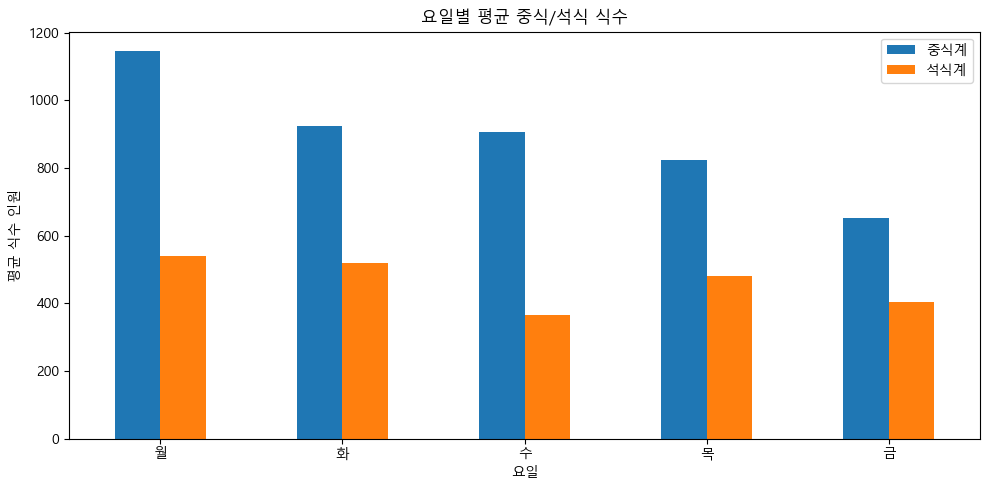

In [11]:
# 이 그래프의 의미:
# 중식/석식이 요일에 따라 평균적으로 어떻게 달라지는지 보여줍니다.
# 왜 중요하나:
# '요일만 달라져도 식수 패턴이 달라진다'는 점을 직관적으로 설명할 수 있습니다.

weekday_summary = train.groupby("요일이름")[["중식계", "석식계"]].mean().reindex(["월","화","수","목","금"])
ax = weekday_summary.plot(kind="bar", figsize=(10, 5), title="요일별 평균 중식/석식 식수")
ax.set_xlabel("요일")
ax.set_ylabel("평균 식수 인원")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


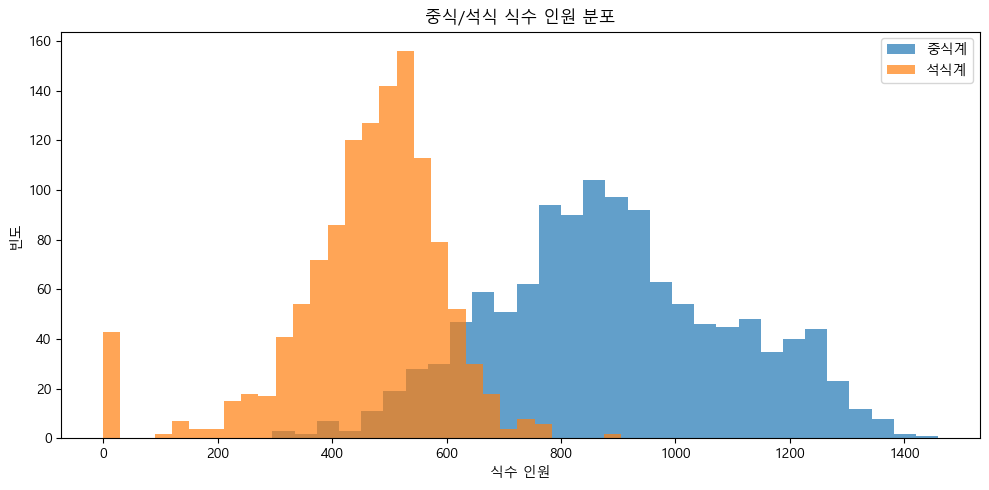

In [12]:
# 이 그래프의 의미:
# 중식과 석식 식수 인원이 전체적으로 어떤 범위에 많이 몰려 있는지 보여줍니다.
# 왜 중요하나:
# 중식은 비교적 크고 안정적이고, 석식은 더 작고 변동이 큰 분포라는 점을 설명할 수 있습니다.

plt.figure(figsize=(10, 5))
plt.hist(train["중식계"], bins=30, alpha=0.7, label="중식계")
plt.hist(train["석식계"], bins=30, alpha=0.7, label="석식계")
plt.title("중식/석식 식수 인원 분포")
plt.xlabel("식수 인원")
plt.ylabel("빈도")
plt.legend()
plt.tight_layout()
plt.show()


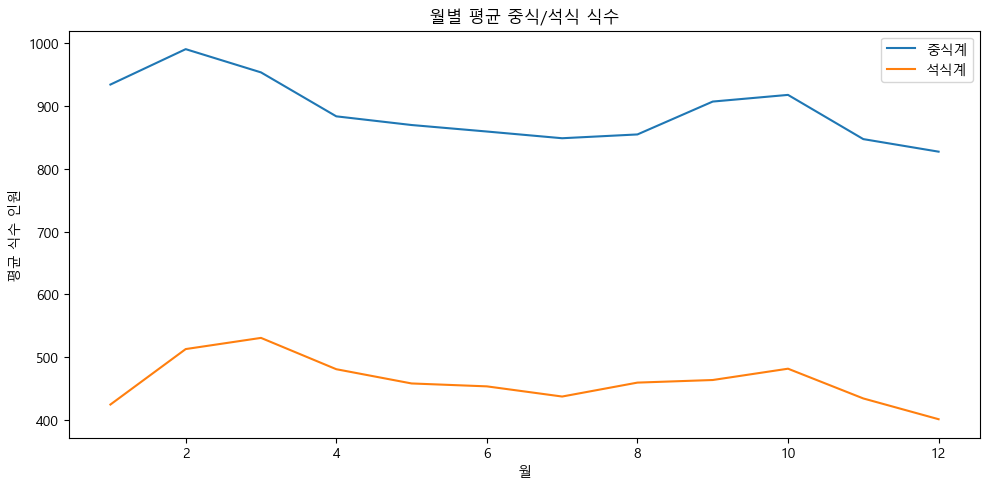

In [13]:
# 이 그래프의 의미:
# 월별로 평균 중식/석식 식수가 어떻게 변하는지 보여줍니다.
# 왜 중요하나:
# 계절, 학사일정, 운영 패턴처럼 시간 흐름에 따라 식수 패턴이 달라질 수 있음을 설명할 수 있습니다.

monthly_summary = train.groupby("월")[["중식계", "석식계"]].mean()
ax = monthly_summary.plot(figsize=(10, 5), title="월별 평균 중식/석식 식수")
ax.set_xlabel("월")
ax.set_ylabel("평균 식수 인원")
plt.tight_layout()
plt.show()


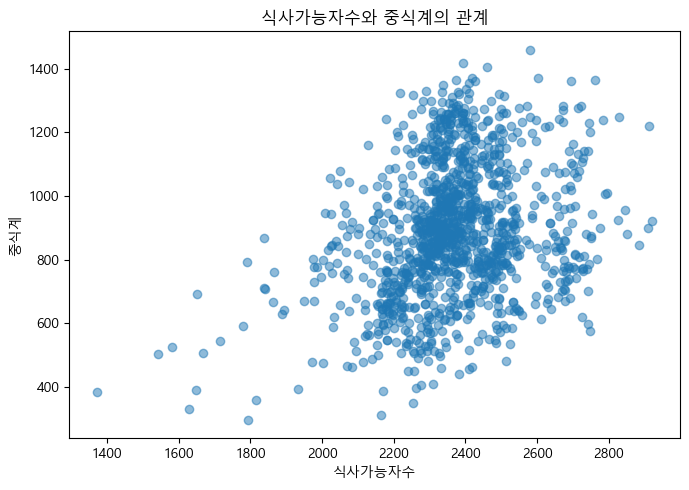

In [14]:
# 이 그래프의 의미:
# 식사가능자수가 많아질수록 실제 중식 인원이 어떻게 늘어나는지 보여줍니다.
# 왜 중요하나:
# 식수 인원 자체보다 '가능한 사람 대비 몇 %가 먹는가'를 보는 참여율 접근이 왜 필요한지 설명할 수 있습니다.

plt.figure(figsize=(7, 5))
plt.scatter(train["식사가능자수"], train["중식계"], alpha=0.5)
plt.title("식사가능자수와 중식계의 관계")
plt.xlabel("식사가능자수")
plt.ylabel("중식계")
plt.tight_layout()
plt.show()


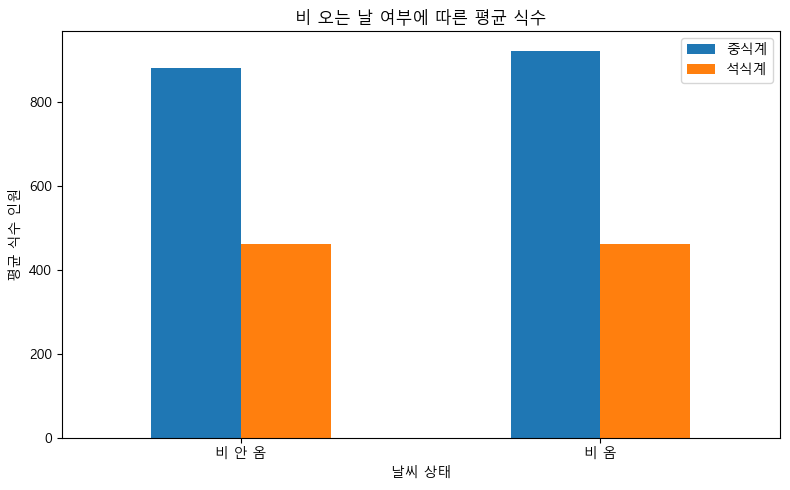

In [15]:
# 이 그래프의 의미:
# 날씨 신호(비 오는 날 여부)에 따라 평균 중식/석식 식수가 어떻게 달라지는지 보여줍니다.
# 왜 중요하나:
# 날씨가 직접 주인공 변수는 아니지만, 사람 행동을 조금 흔드는 보정 신호라는 점을 설명할 수 있습니다.

rain_summary = train.groupby("is_rain")[["중식계", "석식계"]].mean()
rain_summary.index = ["비 안 옴", "비 옴"]
ax = rain_summary.plot(kind="bar", figsize=(8, 5), title="비 오는 날 여부에 따른 평균 식수")
ax.set_xlabel("날씨 상태")
ax.set_ylabel("평균 식수 인원")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


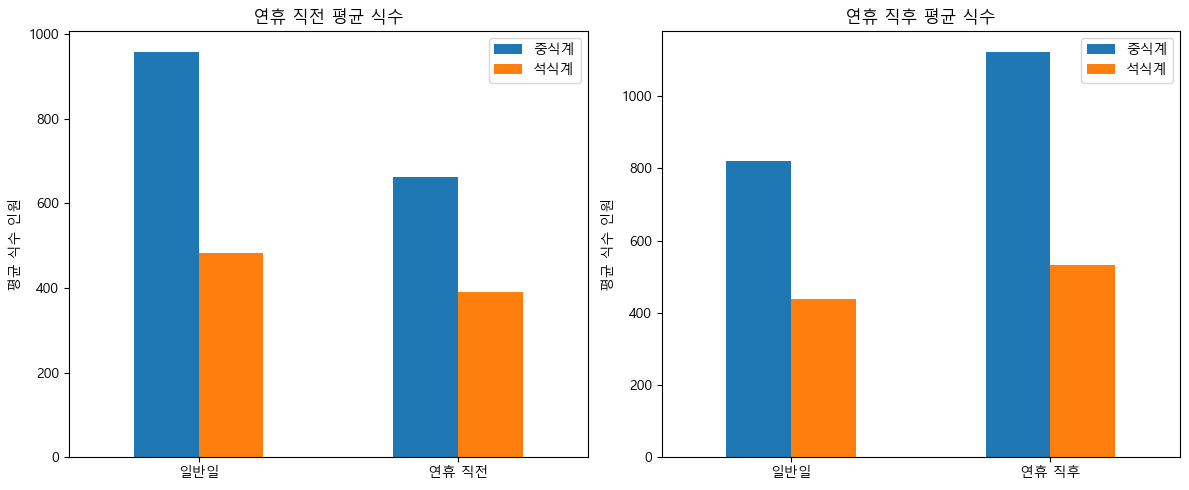

In [16]:
# 이 그래프의 의미:
# 연휴 직전/직후 여부에 따라 평균 중식/석식 식수가 어떻게 달라지는지 보여줍니다.
# 왜 중요하나:
# holiday_before, holiday_after가 왜 weak correction에 들어갔는지 직관적으로 설명할 수 있습니다.

holiday_before_summary = train.groupby("holiday_before")[["중식계", "석식계"]].mean()
holiday_before_summary.index = ["일반일", "연휴 직전"]

holiday_after_summary = train.groupby("holiday_after")[["중식계", "석식계"]].mean()
holiday_after_summary.index = ["일반일", "연휴 직후"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
holiday_before_summary.plot(kind="bar", ax=axes[0], title="연휴 직전 평균 식수")
axes[0].set_xlabel("")
axes[0].set_ylabel("평균 식수 인원")
axes[0].tick_params(axis='x', rotation=0)

holiday_after_summary.plot(kind="bar", ax=axes[1], title="연휴 직후 평균 식수")
axes[1].set_xlabel("")
axes[1].set_ylabel("평균 식수 인원")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


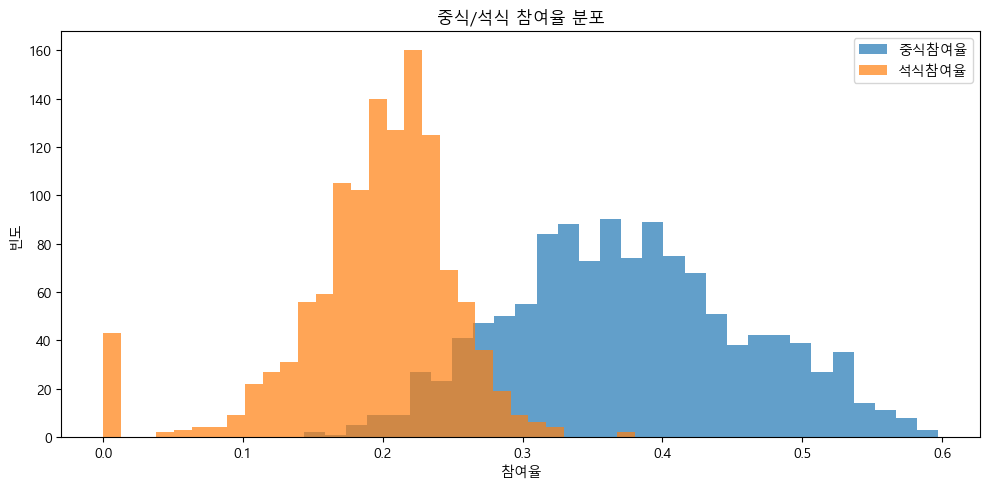

In [17]:
# 이 그래프의 의미:
# 중식 참여율과 석식 참여율의 분포를 보여줍니다.
# 왜 중요하나:
# count보다 참여율이 더 안정적 패턴을 가지는지 감각적으로 설명할 수 있습니다.

plt.figure(figsize=(10, 5))
plt.hist(train["중식참여율"], bins=30, alpha=0.7, label="중식참여율")
plt.hist(train["석식참여율"], bins=30, alpha=0.7, label="석식참여율")
plt.title("중식/석식 참여율 분포")
plt.xlabel("참여율")
plt.ylabel("빈도")
plt.legend()
plt.tight_layout()
plt.show()


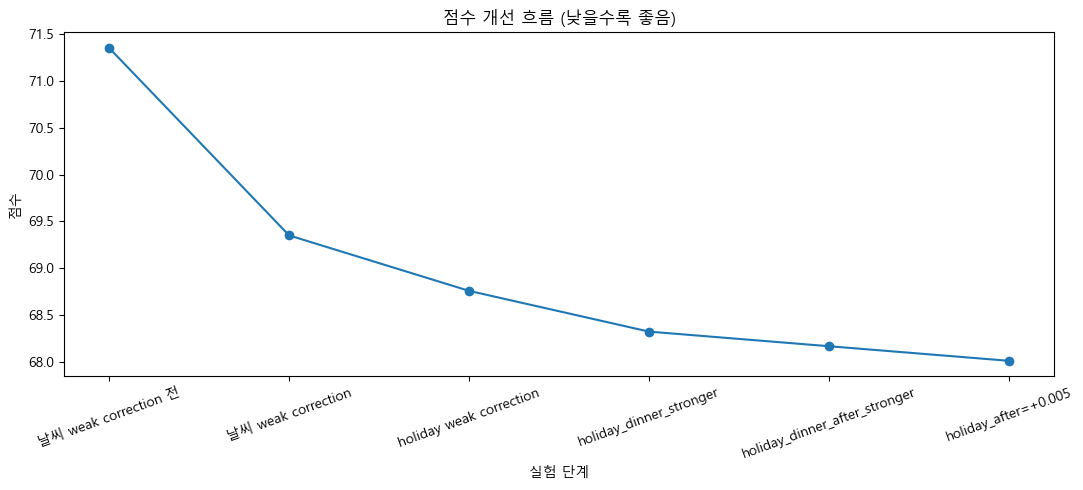

,단계,점수
0,날씨 weak correction 전,71.353403
1,날씨 weak correction,69.348788
2,holiday weak correction,68.755721
3,holiday_dinner_stronger,68.319854
4,holiday_dinner_after_stronger,68.163721
5,holiday_after=+0.005,68.007588


In [18]:
# 이 그래프의 의미:
# 실제로 점수가 어떤 단계에서 얼마나 내려갔는지 보여줍니다.
# 왜 중요하나:
# 모델이 한 번에 좋아진 것이 아니라, 작은 가설 검증을 반복하며 개선됐다는 흐름을 설명할 수 있습니다.

score_flow = pd.DataFrame({
    "단계": [
        "날씨 weak correction 전",
        "날씨 weak correction",
        "holiday weak correction",
        "holiday_dinner_stronger",
        "holiday_dinner_after_stronger",
        "holiday_after=+0.005"
    ],
    "점수": [
        71.3534030334,
        69.3487877105,
        68.7557210438,
        68.3198543772,
        68.1637210438,
        68.0075877105
    ]
})

plt.figure(figsize=(11, 5))
plt.plot(score_flow["단계"], score_flow["점수"], marker="o")
plt.title("점수 개선 흐름 (낮을수록 좋음)")
plt.xlabel("실험 단계")
plt.ylabel("점수")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

display(score_flow)


## 추가 시각화: 석식 · 야근 · 선호 메뉴

발표에서 질문이 자주 나오는 부분인
- 석식과 야근 관계
- 석식 참여율과 석식계 관계
- 선호 메뉴를 약하게 반영한 것이 실제로 의미가 있었는지
를 더 직관적으로 볼 수 있는 그래프를 추가했습니다.


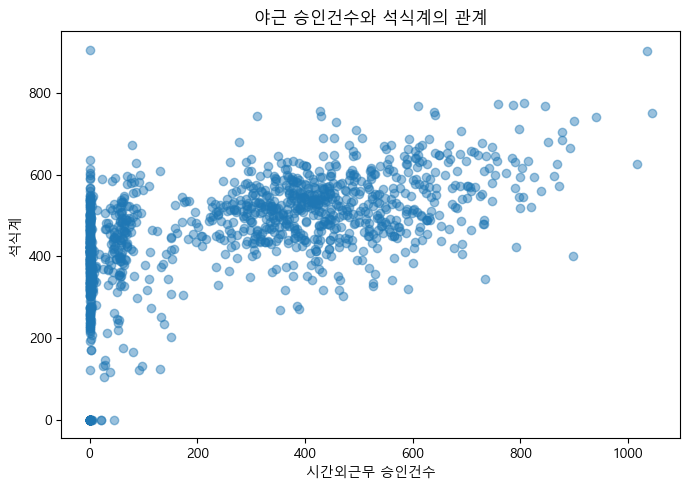

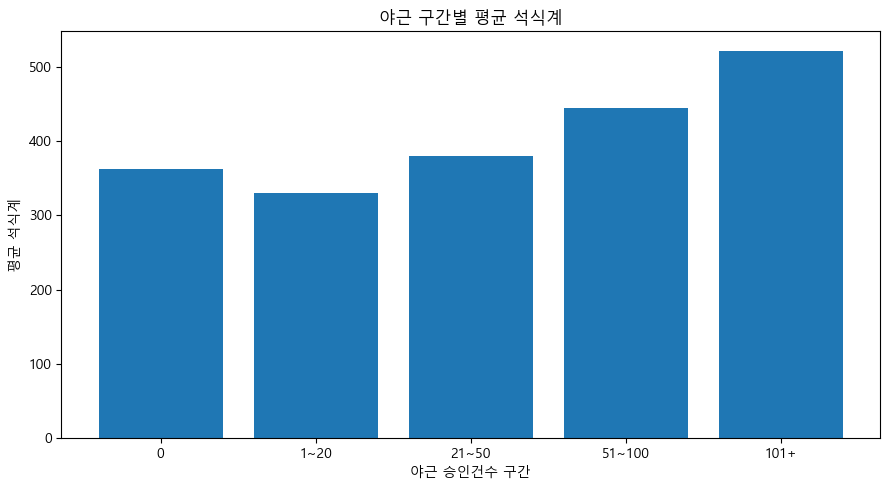

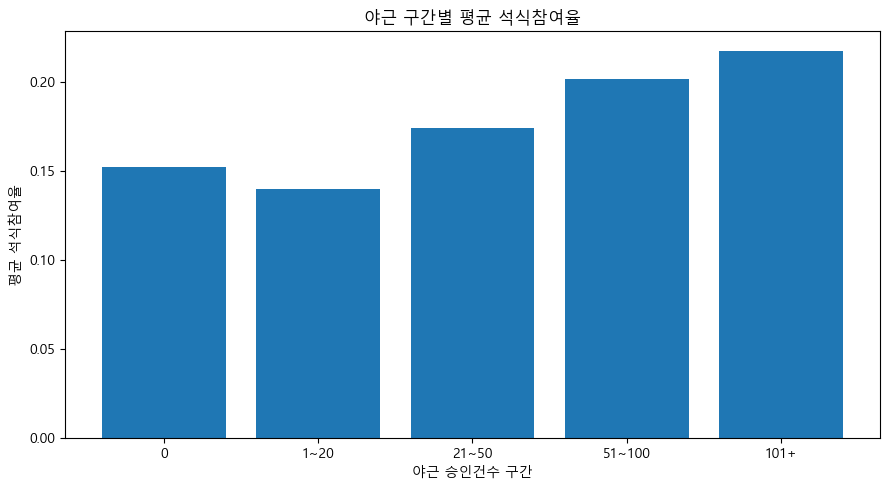

,석식계,석식참여율
본사시간외근무명령서승인건수,,
0,361.768519,0.152540
1~20,330.320000,0.140108
21~50,379.882353,0.174131
51~100,443.772277,0.201932
101+,521.308116,0.217778


In [19]:
# 이 셀의 쓰임:
# 석식과 야근(시간외근무 승인건수)의 관계를 산점도와 구간 평균 그래프로 보여줍니다.
# 왜 넣었나:
# 석식은 중식보다 야근의 영향을 더 많이 받을 가능성이 높아서,
# '야근이 많아질수록 석식 인원과 석식 참여율이 어떻게 달라지는지'를 직관적으로 설명하기 위해 넣었습니다.

plt.figure(figsize=(7, 5))
plt.scatter(train["본사시간외근무명령서승인건수"], train["석식계"], alpha=0.45)
plt.title("야근 승인건수와 석식계의 관계")
plt.xlabel("시간외근무 승인건수")
plt.ylabel("석식계")
plt.tight_layout()
plt.show()

overtime_bin = pd.cut(
    train["본사시간외근무명령서승인건수"],
    bins=[-1, 0, 20, 50, 100, train["본사시간외근무명령서승인건수"].max()],
    labels=["0", "1~20", "21~50", "51~100", "101+"]
)
overtime_summary = train.groupby(overtime_bin)[["석식계", "석식참여율"]].mean()

plt.figure(figsize=(9, 5))
plt.bar(overtime_summary.index.astype(str), overtime_summary["석식계"])
plt.title("야근 구간별 평균 석식계")
plt.xlabel("야근 승인건수 구간")
plt.ylabel("평균 석식계")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.bar(overtime_summary.index.astype(str), overtime_summary["석식참여율"])
plt.title("야근 구간별 평균 석식참여율")
plt.xlabel("야근 승인건수 구간")
plt.ylabel("평균 석식참여율")
plt.tight_layout()
plt.show()

display(overtime_summary)



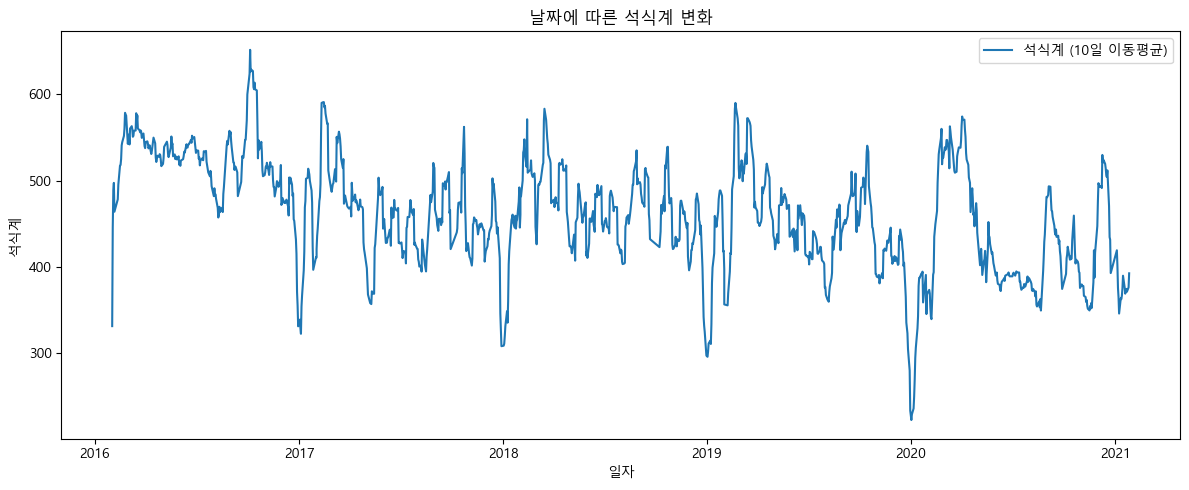

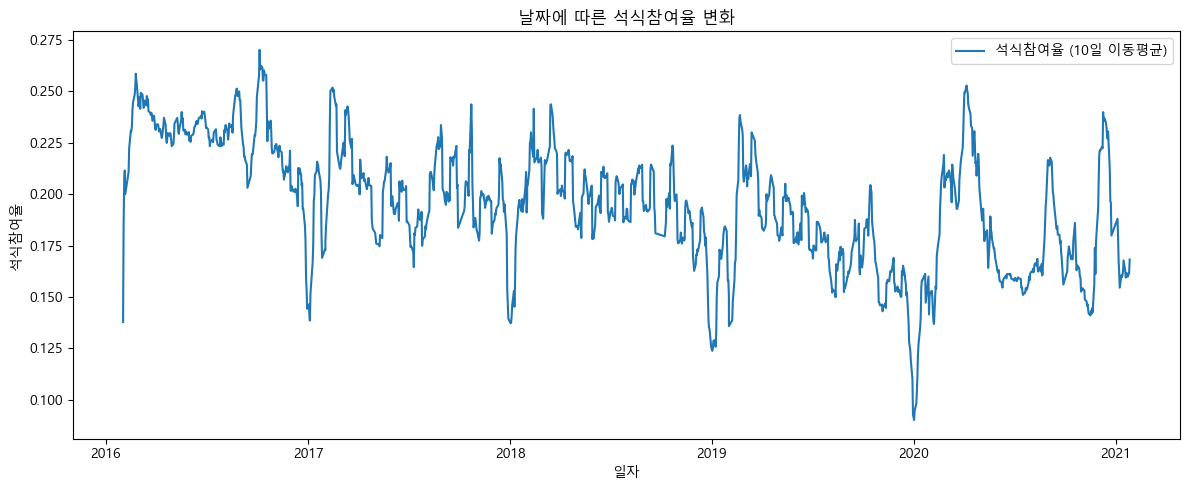

In [20]:
# 이 셀의 쓰임:
# 날짜 흐름에 따라 석식계와 석식 참여율이 함께 어떻게 움직이는지 선그래프로 보여줍니다.
# 왜 넣었나:
# 절대 인원(석식계)과 참여율이 완전히 같은 개념은 아니고,
# 참여율이 왜 더 안정적인 예측 대상인지 시계열 흐름으로 설명하기 위해 넣었습니다.

dinner_line_df = train[["일자", "석식계", "석식참여율"]].sort_values("일자").copy()
dinner_line_df["석식계_이동평균"] = dinner_line_df["석식계"].rolling(10, min_periods=1).mean()
dinner_line_df["석식참여율_이동평균"] = dinner_line_df["석식참여율"].rolling(10, min_periods=1).mean()

plt.figure(figsize=(12, 5))
plt.plot(dinner_line_df["일자"], dinner_line_df["석식계_이동평균"], label="석식계 (10일 이동평균)")
plt.title("날짜에 따른 석식계 변화")
plt.xlabel("일자")
plt.ylabel("석식계")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(dinner_line_df["일자"], dinner_line_df["석식참여율_이동평균"], label="석식참여율 (10일 이동평균)")
plt.title("날짜에 따른 석식참여율 변화")
plt.xlabel("일자")
plt.ylabel("석식참여율")
plt.legend()
plt.tight_layout()
plt.show()


,메뉴,없을 때 중식계,있을 때 중식계,없을 때 참여율,있을 때 참여율
0,치킨,891.678571,864.388889,0.377191,0.360592
1,돈까스,890.428690,859.000000,0.376189,0.378197
2,제육,884.727973,1012.470588,0.374022,0.426401


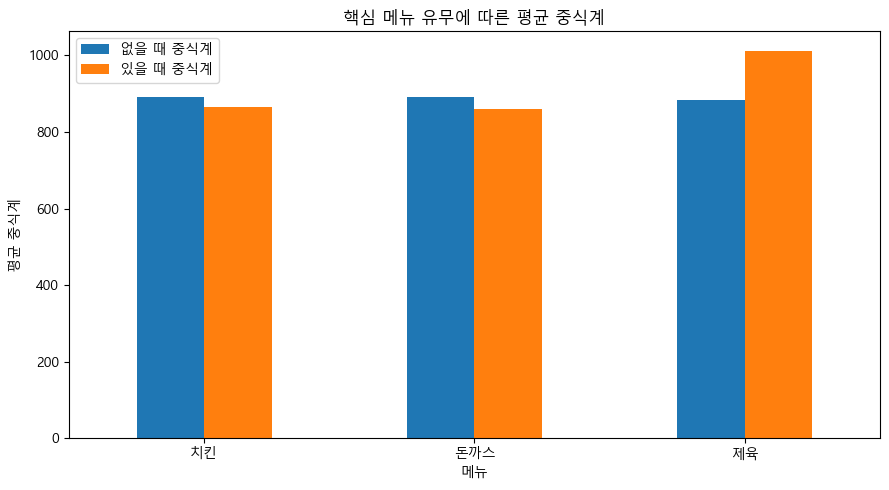

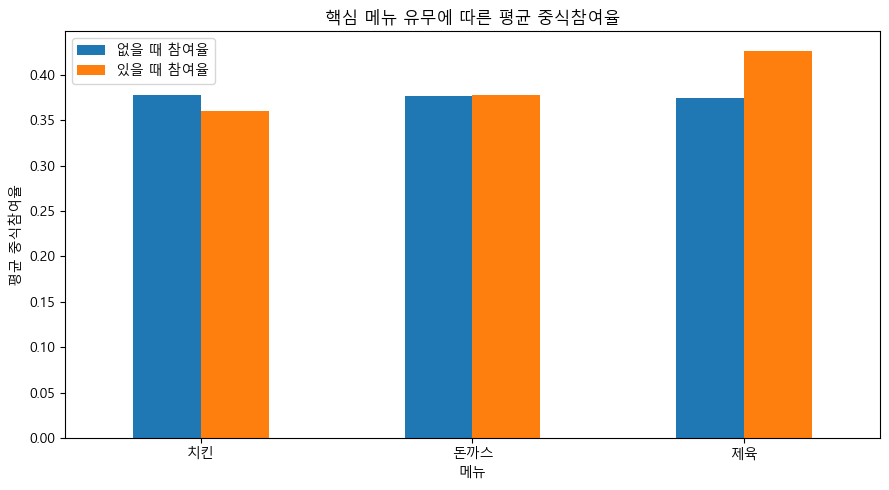

In [21]:
# 이 셀의 쓰임:
# 우리가 '선호될 수 있다'고 가정한 중식 핵심 메뉴(치킨/돈까스/제육)가 실제로 평균 식수에 어떤 차이를 만드는지 보여줍니다.
# 왜 넣었나:
# 메뉴를 직접 강하게 넣지는 않았지만, 적어도 이런 메뉴들이 기본 식수 패턴과 어떤 관련이 있는지
# 시각적으로 보여주면 '왜 메뉴를 weak correction으로 썼는지' 설명하기 쉽기 때문입니다.

menu_viz_df = train.copy()
menu_viz_df["중식메뉴정리"] = menu_viz_df["중식메뉴"].fillna("").astype(str)

menu_viz_df["menu_chicken"] = menu_viz_df["중식메뉴정리"].str.contains("치킨", regex=False).astype(int)
menu_viz_df["menu_donkatsu"] = menu_viz_df["중식메뉴정리"].str.contains("돈까스", regex=False).astype(int)
menu_viz_df["menu_jeyuk"] = menu_viz_df["중식메뉴정리"].str.contains("제육", regex=False).astype(int)

menu_effect_rows = []
for col, name in [
    ("menu_chicken", "치킨"),
    ("menu_donkatsu", "돈까스"),
    ("menu_jeyuk", "제육"),
]:
    summary = menu_viz_df.groupby(col)[["중식계", "중식참여율"]].mean()
    menu_effect_rows.append({
        "메뉴": name,
        "없을 때 중식계": summary.loc[0, "중식계"] if 0 in summary.index else np.nan,
        "있을 때 중식계": summary.loc[1, "중식계"] if 1 in summary.index else np.nan,
        "없을 때 참여율": summary.loc[0, "중식참여율"] if 0 in summary.index else np.nan,
        "있을 때 참여율": summary.loc[1, "중식참여율"] if 1 in summary.index else np.nan,
    })

menu_effect_df = pd.DataFrame(menu_effect_rows)
display(menu_effect_df)

plot_df_count = menu_effect_df.set_index("메뉴")[["없을 때 중식계", "있을 때 중식계"]]
ax = plot_df_count.plot(kind="bar", figsize=(9, 5), title="핵심 메뉴 유무에 따른 평균 중식계")
ax.set_xlabel("메뉴")
ax.set_ylabel("평균 중식계")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

plot_df_rate = menu_effect_df.set_index("메뉴")[["없을 때 참여율", "있을 때 참여율"]]
ax = plot_df_rate.plot(kind="bar", figsize=(9, 5), title="핵심 메뉴 유무에 따른 평균 중식참여율")
ax.set_xlabel("메뉴")
ax.set_ylabel("평균 중식참여율")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [22]:
# 이 셀의 쓰임:
# 핵심 메뉴가 있는 날과 없는 날의 차이를 '한 줄 요약'으로 숫자로 보여줍니다.
# 왜 넣었나:
# 발표할 때 그래프만 보여주면 모호할 수 있어서,
# 실제로 평균이 얼마나 차이 나는지도 함께 보여주기 위해 넣었습니다.

menu_effect_df["중식계 차이(있음-없음)"] = menu_effect_df["있을 때 중식계"] - menu_effect_df["없을 때 중식계"]
menu_effect_df["참여율 차이(있음-없음)"] = menu_effect_df["있을 때 참여율"] - menu_effect_df["없을 때 참여율"]

display(menu_effect_df[["메뉴", "중식계 차이(있음-없음)", "참여율 차이(있음-없음)"]].sort_values("참여율 차이(있음-없음)", ascending=False))


,메뉴,중식계 차이(있음-없음),참여율 차이(있음-없음)
2,제육,127.742616,0.052378
1,돈까스,-31.428690,0.002008
0,치킨,-27.289683,-0.016600


### 석식 핵심 메뉴 효과도 같은 방식으로 보기

중식뿐 아니라 석식에서도 메뉴 스타일이 평균 식수와 참여율에 어떤 차이를 만드는지 함께 확인합니다.


,메뉴스타일,없을 때 석식계,있을 때 석식계,없을 때 참여율,있을 때 참여율
0,중식풍(중화),457.907634,482.880503,0.193771,0.204225
1,양식풍,458.488147,498.765432,0.194277,0.207169
2,분식풍,450.427235,501.189922,0.190884,0.210977


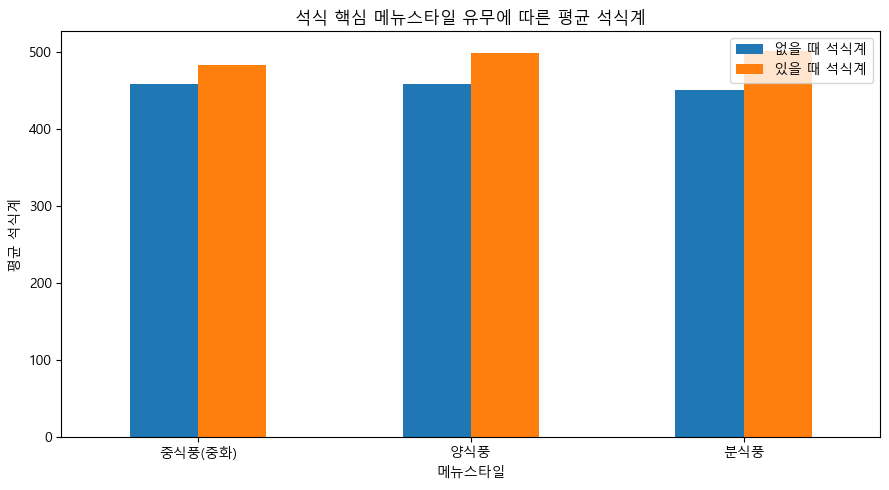

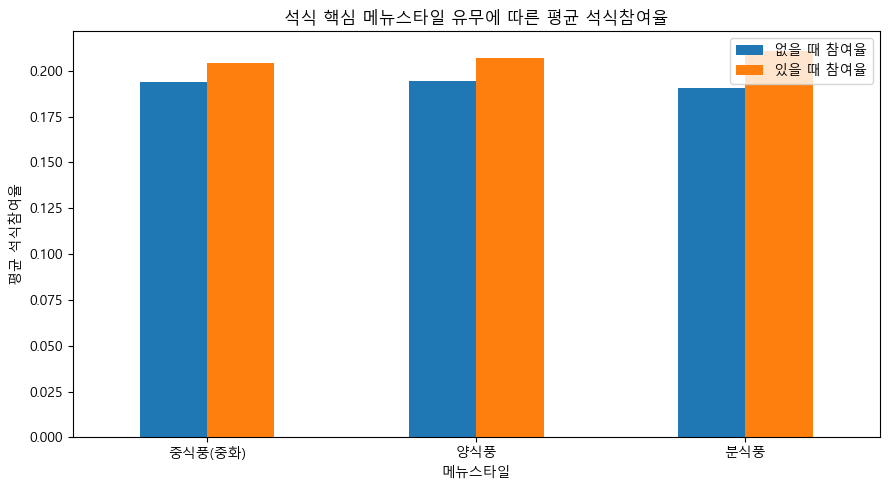

,메뉴스타일,석식계 차이(있음-없음),참여율 차이(있음-없음)
2,분식풍,50.762688,0.020094
1,양식풍,40.277285,0.012892
0,중식풍(중화),24.972869,0.010454


In [23]:
# 이 셀의 쓰임:
# 우리가 선호될 수 있다고 본 석식 핵심 메뉴 스타일(중식과 같은 방식의 약한 메뉴 신호)이
# 실제로 평균 석식계와 석식참여율에 어떤 차이를 만드는지 보여줍니다.
# 왜 넣었나:
# 중식과 동일하게 석식에서도 메뉴가 직접 강한 feature는 아니더라도,
# 약한 보정 신호로 의미가 있는지 시각적으로 확인하기 위해 넣었습니다.

dinner_menu_viz_df = train.copy()
dinner_menu_viz_df["석식메뉴정리"] = dinner_menu_viz_df["석식메뉴"].fillna("").astype(str)

# 석식은 style 기반으로 봤던 흐름을 반영해 대표 스타일 키워드를 단순화
dinner_menu_viz_df["dinner_chinese"] = dinner_menu_viz_df["석식메뉴정리"].str.contains("짜장|짬뽕|탕수|마파|깐풍|유산슬", regex=True).astype(int)
dinner_menu_viz_df["dinner_western"] = dinner_menu_viz_df["석식메뉴정리"].str.contains("돈까스|스테이크|파스타|햄버거|피자|리조또", regex=True).astype(int)
dinner_menu_viz_df["dinner_snack"] = dinner_menu_viz_df["석식메뉴정리"].str.contains("떡볶이|순대|튀김|라볶이|김밥|분식|어묵", regex=True).astype(int)

dinner_effect_rows = []
for col, name in [
    ("dinner_chinese", "중식풍(중화)"),
    ("dinner_western", "양식풍"),
    ("dinner_snack", "분식풍"),
]:
    summary = dinner_menu_viz_df.groupby(col)[["석식계", "석식참여율"]].mean()
    dinner_effect_rows.append({
        "메뉴스타일": name,
        "없을 때 석식계": summary.loc[0, "석식계"] if 0 in summary.index else np.nan,
        "있을 때 석식계": summary.loc[1, "석식계"] if 1 in summary.index else np.nan,
        "없을 때 참여율": summary.loc[0, "석식참여율"] if 0 in summary.index else np.nan,
        "있을 때 참여율": summary.loc[1, "석식참여율"] if 1 in summary.index else np.nan,
    })

dinner_effect_df = pd.DataFrame(dinner_effect_rows)
display(dinner_effect_df)

plot_df_dinner_count = dinner_effect_df.set_index("메뉴스타일")[["없을 때 석식계", "있을 때 석식계"]]
ax = plot_df_dinner_count.plot(kind="bar", figsize=(9, 5), title="석식 핵심 메뉴스타일 유무에 따른 평균 석식계")
ax.set_xlabel("메뉴스타일")
ax.set_ylabel("평균 석식계")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

plot_df_dinner_rate = dinner_effect_df.set_index("메뉴스타일")[["없을 때 참여율", "있을 때 참여율"]]
ax = plot_df_dinner_rate.plot(kind="bar", figsize=(9, 5), title="석식 핵심 메뉴스타일 유무에 따른 평균 석식참여율")
ax.set_xlabel("메뉴스타일")
ax.set_ylabel("평균 석식참여율")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

dinner_effect_df["석식계 차이(있음-없음)"] = dinner_effect_df["있을 때 석식계"] - dinner_effect_df["없을 때 석식계"]
dinner_effect_df["참여율 차이(있음-없음)"] = dinner_effect_df["있을 때 참여율"] - dinner_effect_df["없을 때 참여율"]

display(dinner_effect_df[["메뉴스타일", "석식계 차이(있음-없음)", "참여율 차이(있음-없음)"]].sort_values("참여율 차이(있음-없음)", ascending=False))



In [24]:
# 이 셀의 쓰임:
# 중식과 석식에 사용할 기본 입력 변수 목록을 정의합니다.
# 왜 넣었나:
# 중식과 석식은 반응 패턴이 달라서 같은 피처셋보다 따로 분리했을 때 점수가 더 좋았기 때문입니다.

lunch_features = [
    "월","일","요일","식사가능자수","본사출장자수","본사시간외근무명령서승인건수",
    "is_fri","days_to_month_end","is_month_end_part",
]
dinner_features = [
    "월","일","요일","식사가능자수","본사출장자수","본사시간외근무명령서승인건수",
    "is_wed","has_overtime","log_overtime",
]


In [25]:
# 이 셀의 쓰임:
# 메뉴를 직접 모델에 넣지 않고 keyword/style 플래그로 바꿉니다.
# 왜 넣었나:
# 메뉴를 직접 feature로 넣으면 점수가 자주 깨졌고,
# 메뉴에 따라 생기는 예측 오차를 weak correction으로 조금 보정하는 게 더 잘 맞았기 때문입니다.

lunch_keyword_map = {
    "chicken":"치킨","donkatsu":"돈까스","jeyuk":"제육","curry":"카레",
    "fried_rice":"볶음밥","bibimbap":"비빔밥","jjajang":"짜장","tangsuyuk":"탕수육",
}

def lunch_keyword_flags(text):
    text = normalize_menu_text(text)
    return {f"kw_{k}": int(v in text) for k, v in lunch_keyword_map.items()}

def dinner_style_flags(text):
    text = normalize_menu_text(text)
    flags = {"style_korean":0,"style_chinese":0,"style_western":0,"style_japanese":0,"style_snack":0,"style_fusion":0}
    chinese_kw = ["짜장","짬뽕","탕수","마파","깐풍","유산슬"]
    western_kw = ["돈까스","스테이크","파스타","스프","햄버거","피자","리조또"]
    japanese_kw = ["초밥","우동","가라아게","돈부리","소바"]
    snack_kw = ["떡볶이","순대","튀김","라볶이","김밥","분식","어묵"]
    fusion_kw = ["브리또","타코","샐러드","또띠아","퓨전"]

    if any(k in text for k in chinese_kw): flags["style_chinese"] = 1
    if any(k in text for k in western_kw): flags["style_western"] = 1
    if any(k in text for k in japanese_kw): flags["style_japanese"] = 1
    if any(k in text for k in snack_kw): flags["style_snack"] = 1
    if any(k in text for k in fusion_kw): flags["style_fusion"] = 1
    if sum(flags.values()) == 0: flags["style_korean"] = 1
    return flags

train_lunch_menu = pd.DataFrame([lunch_keyword_flags(x) for x in train["중식메뉴"].fillna("")])
test_lunch_menu = pd.DataFrame([lunch_keyword_flags(x) for x in test["중식메뉴"].fillna("")])
train_dinner_menu = pd.DataFrame([dinner_style_flags(x) for x in train["석식메뉴"].fillna("")])
test_dinner_menu = pd.DataFrame([dinner_style_flags(x) for x in test["석식메뉴"].fillna("")])


In [26]:
# 이 셀의 쓰임:
# XGBoost로 중식/석식 참여율의 기본 예측값을 학습합니다.
# 왜 넣었나:
# 전체 구조의 뼈대는 운영/날짜 변수로 참여율을 먼저 맞추고,
# 메뉴/날씨/holiday는 correction 층으로 덧붙이는 방식이 가장 잘 맞았기 때문입니다.

params = {
    "n_estimators": 1000,
    "learning_rate": 0.05,
    "max_depth": 5,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "min_child_weight": 1,
    "gamma": 0.0,
}

X_train_lunch = train[lunch_features]
X_test_lunch = test[lunch_features]
y_lunch = train["중식참여율"]

X_train_dinner = train[dinner_features]
X_test_dinner = test[dinner_features]
y_dinner = train["석식참여율"]

xgb_lunch = XGBRegressor(objective="reg:squarederror", random_state=42, **params)
xgb_dinner = XGBRegressor(objective="reg:squarederror", random_state=42, **params)

xgb_lunch.fit(X_train_lunch, y_lunch)
xgb_dinner.fit(X_train_dinner, y_dinner)

base_pred_lunch_ratio = np.clip(xgb_lunch.predict(X_test_lunch), 0, 1.5)
base_pred_dinner_ratio = np.clip(xgb_dinner.predict(X_test_dinner), 0, 1.5)

train_pred_lunch_ratio = np.clip(xgb_lunch.predict(X_train_lunch), 0, 1.5)
train_pred_dinner_ratio = np.clip(xgb_dinner.predict(X_train_dinner), 0, 1.5)

train["lunch_residual"] = train["중식참여율"] - train_pred_lunch_ratio
train["dinner_residual"] = train["석식참여율"] - train_pred_dinner_ratio


In [27]:
# 이 셀의 쓰임:
# 메뉴 weak correction을 계산합니다.
# 왜 넣었나:
# 기본 모델이 메뉴별로 얼마나 과소/과대예측했는지를 residual 평균으로 계산해,
# 최종 참여율을 아주 조금만 보정하기 위해 넣었습니다.

LUNCH_SHRINK = 0.35
DINNER_SHRINK = 0.35
RAW_CLIP = 0.03
FINAL_CLIP = 0.04

lunch_corr = {}
for col in train_lunch_menu.columns:
    mask = train_lunch_menu[col] == 1
    lunch_corr[col] = train.loc[mask, "lunch_residual"].mean() if mask.sum() >= 5 else 0.0

dinner_corr = {}
for col in train_dinner_menu.columns:
    mask = train_dinner_menu[col] == 1
    dinner_corr[col] = train.loc[mask, "dinner_residual"].mean() if mask.sum() >= 5 else 0.0

for k in lunch_corr:
    lunch_corr[k] = float(np.clip(lunch_corr[k] * LUNCH_SHRINK, -RAW_CLIP, RAW_CLIP))
for k in dinner_corr:
    dinner_corr[k] = float(np.clip(dinner_corr[k] * DINNER_SHRINK, -RAW_CLIP, RAW_CLIP))

lunch_menu_adj = np.zeros(len(test))
for col in test_lunch_menu.columns:
    lunch_menu_adj += test_lunch_menu[col].values * lunch_corr.get(col, 0.0)

dinner_menu_adj = np.zeros(len(test))
for col in test_dinner_menu.columns:
    dinner_menu_adj += test_dinner_menu[col].values * dinner_corr.get(col, 0.0)

lunch_menu_adj = np.clip(lunch_menu_adj, -FINAL_CLIP, FINAL_CLIP)
dinner_menu_adj = np.clip(dinner_menu_adj, -FINAL_CLIP, FINAL_CLIP)


In [28]:
# 이 셀의 쓰임:
# 날씨 weak correction을 적용합니다.
# 왜 넣었나:
# 날씨를 직접 feature로 넣는 방식은 잘 안 맞았지만,
# 비/더위/추위를 약한 보정 신호로 주자 점수가 크게 좋아졌기 때문입니다.

weather_lunch_signal = np.clip(
    0.010 * test["is_rain"].values
    - 0.006 * test["is_hot"].values
    + 0.004 * test["is_cold"].values,
    -0.02, 0.02
)

weather_dinner_signal = np.clip(
    0.004 * test["is_rain"].values
    + 0.003 * test["is_cold"].values,
    -0.015, 0.015
)


In [29]:
# 이 셀의 쓰임:
# holiday weak correction을 적용합니다.
# 왜 넣었나:
# 연휴 전/후는 실제 식수 행동을 흔드는 요인이었고,
# 실험 결과 석식은 holiday_after 쪽이 가장 강하게 먹혔습니다.

holiday_lunch_signal = np.clip(
    -0.004 * test["holiday_before"].values
    + 0.003 * test["holiday_after"].values,
    -0.010, 0.010
)

holiday_dinner_signal = np.clip(
    -0.005 * test["holiday_before"].values
    + 0.005 * test["holiday_after"].values,
    -0.010, 0.012
)

final_pred_lunch_ratio = np.clip(
    base_pred_lunch_ratio + lunch_menu_adj + weather_lunch_signal + holiday_lunch_signal,
    0, 1.5
)
final_pred_dinner_ratio = np.clip(
    base_pred_dinner_ratio + dinner_menu_adj + weather_dinner_signal + holiday_dinner_signal,
    0, 1.5
)

print("holiday_lunch mean:", holiday_lunch_signal.mean(), "min/max:", holiday_lunch_signal.min(), holiday_lunch_signal.max())
print("holiday_dinner mean:", holiday_dinner_signal.mean(), "min/max:", holiday_dinner_signal.min(), holiday_dinner_signal.max())


holiday_lunch mean: -0.0002 min/max: -0.004 0.003
holiday_dinner mean: 0.0 min/max: -0.005 0.005


In [30]:
# 이 셀의 쓰임:
# 최종 참여율을 실제 식수 인원으로 바꾸고 제출 파일을 저장합니다.
# 왜 넣었나:
# 대회 제출은 중식계/석식계 인원 수가 필요하므로, 마지막에 참여율을 인원으로 환산합니다.

pred_lunch_count = np.clip(final_pred_lunch_ratio * test["식사가능자수"].values, 0, None)
pred_dinner_count = np.clip(final_pred_dinner_ratio * test["식사가능자수"].values, 0, None)

submission = sample_submission.copy()
if "중식계" in submission.columns and "석식계" in submission.columns:
    lunch_col = "중식계"
    dinner_col = "석식계"
else:
    numeric_like_cols = [c for c in submission.columns if c != submission.columns[0]]
    lunch_col, dinner_col = numeric_like_cols[:2]

submission[lunch_col] = pred_lunch_count
submission[dinner_col] = pred_dinner_count

save_name = "submission/submission_v2.csv"
submission.to_csv(save_name, index=False, encoding="utf-8-sig")
print("저장 완료:", save_name)
display(submission.head())


저장 완료: submission/submission_v2.csv


,일자,중식계,석식계
0,2021-01-27,1002.020719,202.146080
1,2021-01-28,1012.558540,472.116173
2,2021-01-29,572.345312,244.279198
3,2021-02-01,1221.143712,550.104567
4,2021-02-02,1022.554668,573.191660
